In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

## Proyecto K vecinos

In [211]:
archivo = "../data/raw/winequality-red.csv" 
df = pd.read_csv(archivo, sep=";")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [213]:
df.duplicated().sum()

np.int64(240)

In [214]:
df = df.drop_duplicates()

In [215]:
df.duplicated().sum()

np.int64(0)

In [216]:
df.shape

(1359, 12)

In [217]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

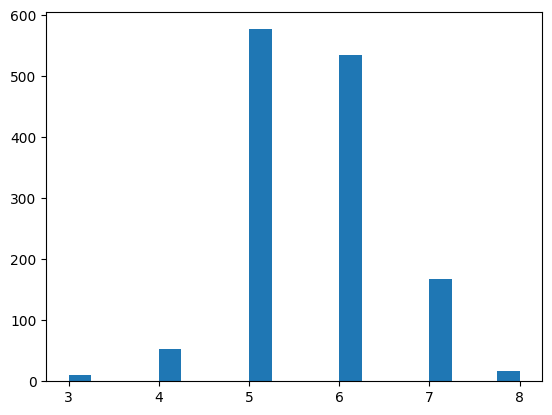

In [218]:
plt.hist(df["quality"].dropna(), bins=20)
plt.show()

## Observaciones

> Explorando los datos del Eda y limpiandolos observamos que la mayoria de los vinos del Dataset esta entre 5 y 6 de calidad. Definire como 3, 4 y 5 como los vinos de menor calidad, los 6 y 7 como vinos de calidad media y dejare la exclusividad del 8 para vinos de alta calidad. 

In [219]:
df["quality"].value_counts(dropna=False)

quality
5    577
6    535
7    167
4     53
8     17
3     10
Name: count, dtype: int64

In [220]:
df["quality"] = np.select(
    [
        df["quality"].isin([3, 4, 5]),
        df["quality"].isin([6, 7]),
        df["quality"].eq(8)
    ],
    [0, 1, 2],
    default=df["quality"]  
)

In [221]:
df["quality"].value_counts()

quality
1    702
0    640
2     17
Name: count, dtype: int64

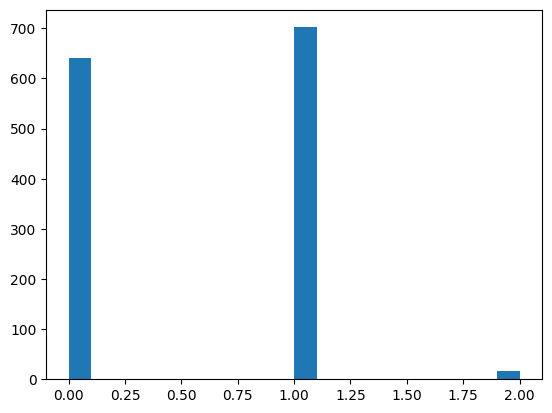

In [222]:
plt.hist(df["quality"].dropna(), bins=20)
plt.show()

In [223]:
X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
472,12.5,0.370,0.55,2.6,0.083,25.0,68.0,0.9995,3.15,0.82,10.4
25,6.3,0.390,0.16,1.4,0.080,11.0,23.0,0.9955,3.34,0.56,9.3
691,9.2,0.920,0.24,2.6,0.087,12.0,93.0,0.9998,3.48,0.54,9.8
240,8.9,0.635,0.37,1.7,0.263,5.0,62.0,0.9971,3.00,1.09,9.3
1218,8.2,0.400,0.31,1.9,0.082,8.0,24.0,0.9960,3.24,0.69,10.6


In [224]:
num_variables = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
norm_scaler = StandardScaler()

X_train[num_variables] = norm_scaler.fit_transform(X_train[num_variables])
X_test[num_variables] = norm_scaler.transform(X_test[num_variables])

In [225]:
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
472,2.469470,-0.886437,1.500319,0.045941,-0.086985,0.897521,0.645904,1.521389,-1.046907,0.977564,-0.041925
25,-1.123678,-0.776580,-0.547494,-0.810134,-0.151118,-0.472093,-0.726185,-0.603816,0.170124,-0.583335,-1.044865
691,0.556988,2.134635,-0.127430,0.045941,-0.001475,-0.374263,1.408176,1.680780,1.066884,-0.703404,-0.588983
240,0.383126,0.569170,0.555175,-0.596116,3.760980,-1.059070,0.462959,0.246266,-2.007721,2.598498,-1.044865
1218,-0.022552,-0.721651,0.240126,-0.453436,-0.108363,-0.765582,-0.695694,-0.338166,-0.470419,0.197114,0.140427


In [235]:
# Modelo
model = KNeighborsClassifier(n_neighbors=5)

# Entrenamiento
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [236]:
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

In [237]:
accuracy = {'Accuracy Test': accuracy_score(y_test, y_pred_test),
            'Accuracy Train': accuracy_score(y_train, y_pred_train)}
accuracy

{'Accuracy Test': 0.6985294117647058, 'Accuracy Train': 0.7884084636614536}

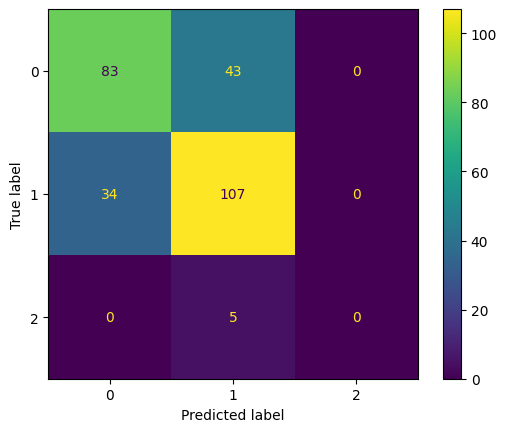

In [247]:
grid_confusion_matrix = confusion_matrix(y_test, y_pred_test)
ConfusionMatrixDisplay(grid_confusion_matrix).plot()
plt.show()


## Hiperparametrización

In [229]:
hiper_params = {'n_neighbors': [11, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35],
                'weights': ['uniform', 'distance'],
                'p': [1, 2]}

In [230]:
random_search = RandomizedSearchCV(estimator=model,
                                   param_distributions=hiper_params,
                                   n_iter=50,
                                   cv=5,
                                   scoring='accuracy',
                                   random_state=42,
                                   n_jobs=-1)

random_search.fit(X_train, y_train)
random_search.best_params_

{'weights': 'distance', 'p': 1, 'n_neighbors': 35}

In [231]:
random_search.best_score_

np.float64(0.7479178116940769)

In [232]:
best_knn = random_search.best_estimator_
y_pred = best_knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_accuracy

0.7095588235294118

In [234]:
y_pred_test = random_search.predict(X_test)
y_pred_train = random_search.predict(X_train)

accuracy = {'Accuracy Test': accuracy_score(y_test, y_pred_test),
            'Accuracy Train': accuracy_score(y_train, y_pred_train)}
accuracy

{'Accuracy Test': 0.7095588235294118, 'Accuracy Train': 1.0}